## Module 8: Recurrent Neural Networks (LSTMs & GRUs)
### ETH-USD


# 1. Install and Import LibrariesLibraries

In [1]:
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    GRU,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# 2. Download Financial Dataset

In [3]:
# Ethereum Price Data
df = yf.download("ETH-USD", start="2020-01-01")

# Keep only closing prices
df = df[['Close']]

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker         ETH-USD
Date                  
2020-01-01  130.802002
2020-01-02  127.410179
2020-01-03  134.171707
2020-01-04  135.069366
2020-01-05  136.276779


# 3. Visualize Data

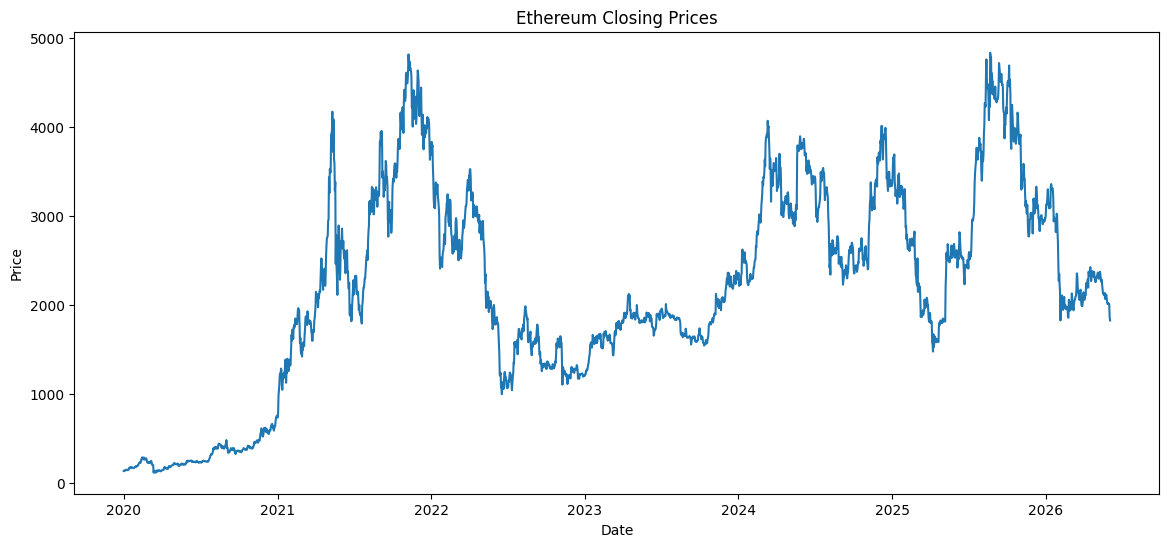

In [4]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'])
plt.title("Ethereum Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# 4. Normalize Data

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

# 5. Create Sequences (Sliding Window)

In [6]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 30
X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2316, 30, 1)
y Shape: (2316, 1)


# 6. Train-Test Split (Chronological)

In [7]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1852
Testing Samples: 464


# 7. Build Stacked LSTM Model

In [8]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 8. Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Callbacks

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    save_best_only=True
)

# 10. Train Model

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0197 - mae: 0.0907 - val_loss: 0.0054 - val_mae: 0.0588 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043 - mae: 0.0462 - val_loss: 0.0056 - val_mae: 0.0631 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0037 - mae: 0.0425 - val_loss: 0.0036 - val_mae: 0.0494 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039 - mae: 0.0425 - val_loss: 0.0024 - val_mae: 0.0377 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - mae: 0.0358 - val_loss: 0.0024 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - mae: 0.0353 - val_loss: 0.0020 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0024 - mae: 0.0337 - val_loss: 0.0023 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 

# 11. Plot Training History

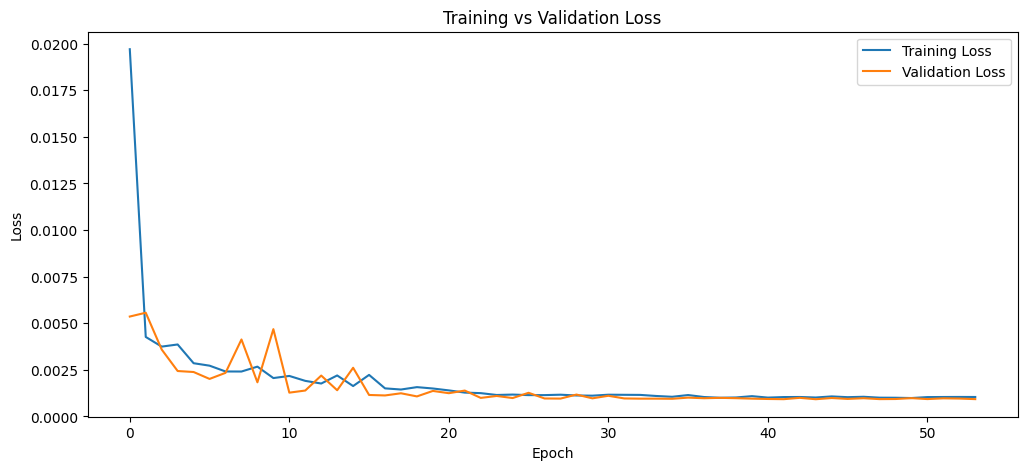

In [12]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# 12. Predictions

In [13]:
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


# 13. Evaluation Metrics

In [14]:
mae = mean_absolute_error(y_test_actual, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test_actual, predictions)
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 108.38517524456155
RMSE: 150.94566002862967


# 14. Visualize Predictions

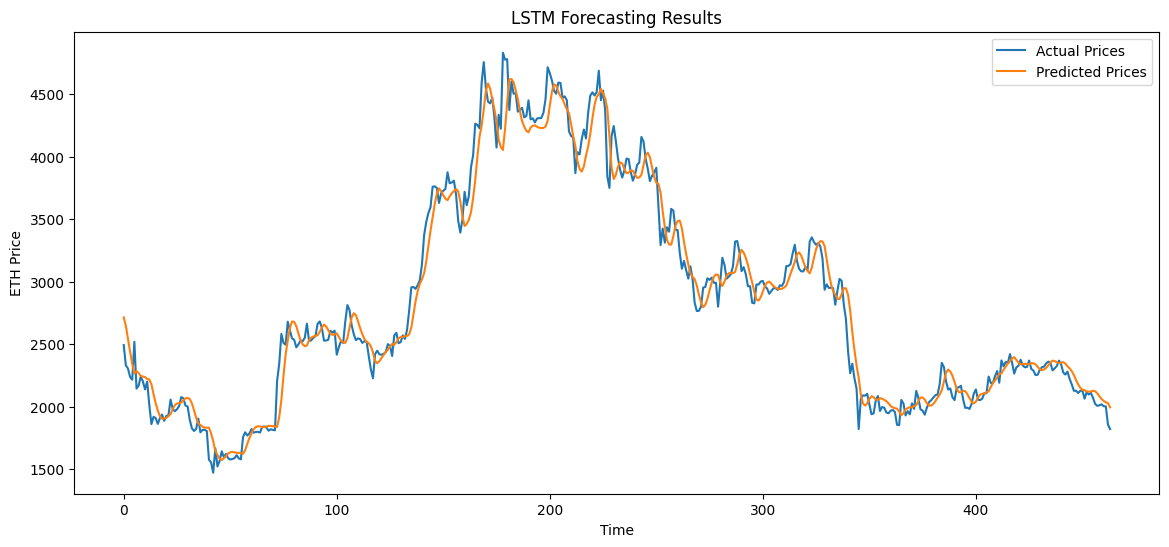

In [15]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.title("LSTM Forecasting Results")
plt.xlabel("Time")
plt.ylabel("ETH Price")

plt.legend()
plt.show()

# 15. GRU Model

In [16]:
gru_model = Sequential()

gru_model.add(
    GRU(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(
    GRU(
        units=64
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(32, activation='relu'))
gru_model.add(Dense(1))

# Compile
gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,937 (156.00 KB)

 Trainable params: 39,937 (156.00 KB)

 Non-trainable params: 0 (0.00 B)

# 16. Train GRU Model

In [17]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0223 - mae: 0.1002 - val_loss: 0.0011 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029 - mae: 0.0362 - val_loss: 0.0013 - val_mae: 0.0284 - learning_rate: 0.0010
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0020 - mae: 0.0308 - val_loss: 0.0034 - val_mae: 0.0498 - learning_rate: 0.0010
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0020 - mae: 0.0309 - val_loss: 0.0032 - val_mae: 0.0483 - learning_rate: 0.0010
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0020 - mae: 0.0307 - val_loss: 0.0016 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0017 - mae: 0.0285 - val_loss: 0.0017 - val_mae: 0.0339 - learning_rate: 5.0000e-04
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - mae: 0.0282 - val_loss: 9.2792e-04 - val_mae: 0.0236 - learning_rate: 5.000

# 17. GRU Predictions

In [18]:

gru_predictions = gru_model.predict(X_test)

gru_predictions = scaler.inverse_transform(gru_predictions)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


# 18. GRU Evaluation

In [19]:
gru_mae = mean_absolute_error(
    y_test_actual,
    gru_predictions
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_predictions
    )
)

print("GRU MAE :", gru_mae)
print("GRU RMSE:", gru_rmse)

GRU MAE : 117.73641178525727
GRU RMSE: 168.67628626388844


# 19. Compare LSTM vs GRU

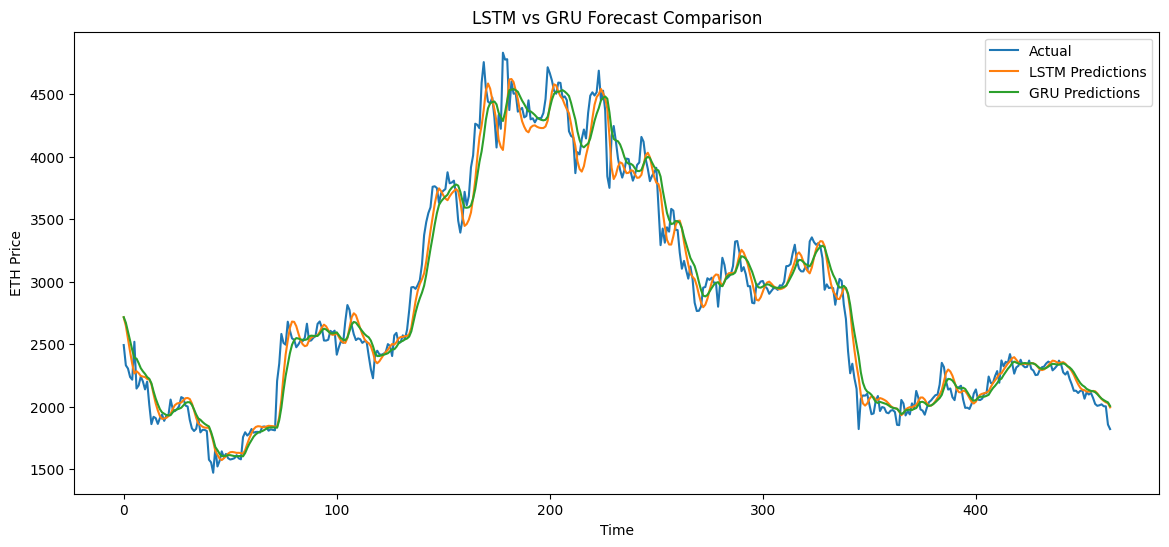

In [20]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual')

plt.plot(predictions, label='LSTM Predictions')

plt.plot(gru_predictions, label='GRU Predictions')

plt.title("LSTM vs GRU Forecast Comparison")

plt.xlabel("Time")
plt.ylabel("ETH Price")

plt.legend()

plt.show()

# 20. Optional: Bidirectional LSTM

In [21]:
bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        ),
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

bilstm_model.add(Dropout(0.2))
bilstm_model.add(
    Bidirectional(
        LSTM(64)
    )
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(1))

# Compile
bilstm_model.compile(
    optimizer='adam',
    loss='mse'
)

bilstm_model.summary()

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,737 (518.50 KB)

 Trainable params: 132,737 (518.50 KB)

 Non-trainable params: 0 (0.00 B)

# 21. Train Bidirectional LSTM

In [22]:
bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0103 - val_loss: 0.0032
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0035 - val_loss: 0.0023
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0016 - val_loss: 0.0026


# 22. Final Notes

This chapter demonstrated:

1. Sequential deep learning for time series
2. Sliding window sequence generation
3. Stacked LSTM architecture
4. GRU implementation
5. Bidirectional LSTM
6. Regularization using Dropout
7. Early stopping
8. Learning rate scheduling
9. Financial forecasting workflow
10. Deep learning evaluation metrics